# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load Data

#### Step 1 : Import Time Related, Freq Related, and Joint Related Features

In [10]:
time_rel_features = (pd.read_pickle("../data/feature_mart/train_features.pkl")
                        .reset_index(drop = False)
                            .rename(columns = {"index":"key"})) # Time-Related Features 
freq_rel_features = (pd.read_pickle("../data/feature_mart/train_frequency_features.pkl")
                    .reset_index(drop = False)
                        .rename(columns = {"index":"key"})) # Frequency Related Features
joint_rel_features = (pd.read_pickle("../data/feature_mart/train_join_features.pkl") 
                        .reset_index(drop = False)
                            .rename(columns = {"index":"key"}))# Joint Features

In [11]:
print(f"Time Related Features: {time_rel_features.shape}")
print(f"Frequency Related Features: {freq_rel_features.shape}")
print(f"Time-Frequency Related Features: {joint_rel_features.shape}")

Time Related Features: (4890, 777)
Frequency Related Features: (4890, 649)
Time-Frequency Related Features: (4890, 649)


#### Step 2 : Preprocessing Dataset

In [ ]:
try:
    assert((pd.merge(time_rel_features.drop("epoch_data_ICA", axis = 1),
            freq_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left")).shape[0] == time_rel_features.shape[0])

    train_df = (pd.merge(time_rel_features.drop("epoch_data_ICA", axis = 1),
            freq_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left"))
    
    print("====== SUCCESS : JOIN OPERATION BETWEEN TIME RELATED FEATURES AND FREQUENCY RELATED FEATURES ======")
except Exception as e:
    print("====== FAILED : JOIN OPERATION BETWEEN TIME RELATED FEATURES AND FREQUENCY RELATED FEATURES ======")
    



try:
    assert((pd.merge(train_df,
            joint_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left")).shape[0] == time_rel_features.shape[0])

    train_df = (pd.merge(train_df,
            joint_rel_features.drop("epoch_data_ICA", axis = 1), 
            on = ['subject', 'trial', 'trail_type', 'label', 'label_description', 'shape', "key"], 
            how = "left"))
    
    print("====== SUCCESS : JOIN OPERATION BETWEEN TIME, FREQUENCY RELATED FEATURES AND JOINT RELATED FEATURES ======")
except Exception as e:
    print("====== FAILED : JOIN OPERATION BETWEEN TIME, FREQUENCY RELATED FEATURES AND JOINT RELATED FEATURES ======")
    



====== SUCCESS : JOIN OPERATION BETWEEN TIME RELATED FEATURES AND FREQUENCY RELATED FEATURES ======
====== SUCCESS : JOIN OPERATION BETWEEN TIME, FREQUENCY RELATED FEATURES AND JOINT RELATED FEATURES ======


In [22]:
del time_rel_features, freq_rel_features, joint_rel_features

In [66]:
X = train_df.drop(['key', 'subject', 'trial', 'trail_type', 'label', 'label_description',
       'shape', 'epoch_data_ICA_inds_x', "epoch_data_ICA_inds_y", "epoch_data_ICA_inds"], axis = 1) # features
y = train_df["label"] # label

print(f"Shape of X : {X.shape}")
print(f"Shape of y : {y.shape}")

Shape of X : (4890, 2048)
Shape of y : (4890,)


#### Step 3 : Splitting Dataset into Train, Validation

In [67]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, stratify= y)

print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_val.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of y_test : {y_val.shape}")

Shape of X_train : (3912, 2048)
Shape of X_test : (978, 2048)
Shape of y_train : (3912,)
Shape of y_test : (978,)


#### Step 4: Save the DataFrame

In [24]:
X_train.to_pickle("../data/training/X_train.pkl")
X_val.to_pickle("../data/training/X_val.pkl")
y_train.to_pickle("../data/training/y_train.pkl")
y_val.to_pickle("../data/training/y_val.pkl")

# Visualizing T-SNE and PCA

In [74]:
y_dummy = y_train
X_dummy = X_train

In [75]:
def TSNE_PCA(X, y):
    # Encode categorical labels to numeric
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_
    
    # Standardize features
    #X_scaled = StandardScaler().fit_transform(X)
    X_scaled = X

    # ---- PCA ----
    pca = PCA(n_components=3, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # ---- t-SNE ----
    tsne = TSNE(n_components=3, random_state=42, perplexity=30, learning_rate=200)
    X_tsne = tsne.fit_transform(X_scaled)
    
    return X_pca, y_encoded, X_tsne

X_pca, y_encoded, X_tsne = TSNE_PCA(X_dummy.to_numpy(), y_dummy.to_numpy())

<Axes: >

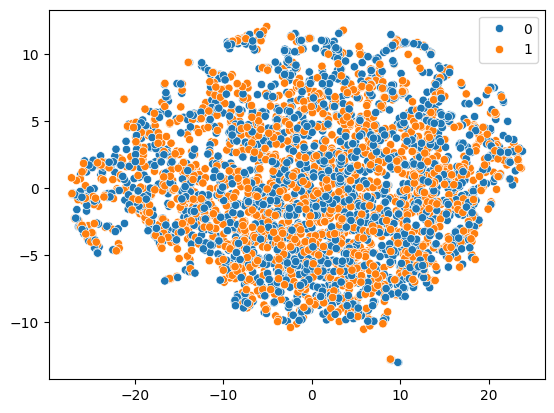

In [76]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:, 1], hue=y_encoded)

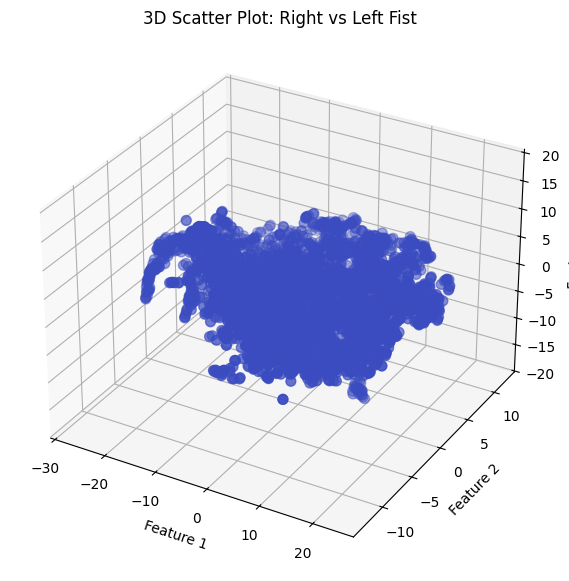

In [77]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def plotly_2D_graph(X_pca):
    # Pick three features/columns for 3D plotting
    x = X_pca[:, 0]   # feature 1
    y = X_pca[:, 1]   # feature 2
    z = X_pca[:, 2]   # feature 3

    # Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, c=(y_dummy == "right_fist").astype(int), cmap='coolwarm', s=50)

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")
    ax.set_title("3D Scatter Plot: Right vs Left Fist")

    plt.show()

plotly_2D_graph(X_tsne)

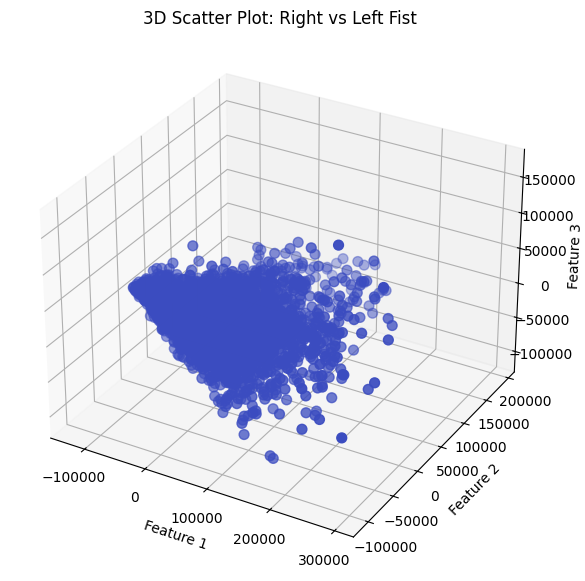

In [80]:
plotly_2D_graph(X_pca)

In [78]:
import plotly.express as px

def plotly_3D_graph(data):
    # Take first 3 features for 3D plotting
    x = data[:, 0]   # feature 1
    y = data[:, 1]   # feature 2
    z = data[:, 2]   # feature 3

    # Create 3D scatter plot
    fig = px.scatter_3d(
        x=x,
        y=y,
        z=z,
        color=y_dummy,   # colors by class (right_fist / left_fist)
        symbol=y_dummy,  # optional: different marker symbols per class
        title="3D Scatter Plot: Right vs Left Fist"
    )

    fig.update_traces(marker=dict(size=5, opacity=0.8))
    fig.show()
    

plotly_3D_graph(X_tsne)

In [81]:
plotly_3D_graph(X_pca)